In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from genkit.inspect import estimate_init_error, estimate_training_error, model_est_jacobian_spectral_curve
from genkit.metrics import metric_on_quantile, mssle
from labkit.report import PRETTY_RCPARAMS
from labkit.report import format_mean_std_latex


/home/hcherkaoui/src/flowbench/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.rcParams.update(PRETTY_RCPARAMS)


In [3]:
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "src" / "genkit").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from benchmarks.analysis._utils import (
    METRIC_ORDER,
    aggregated_best_alpha,
    best_table_df,
    evaluate_run,
    load_generator,
    load_train_stats,
    reduce_best_alpha,
    reduce_best_alpha_runs,
    run_dirs,
    setting_code,
    summarize_exact,
    summarize_runs,
)

In [4]:
def grouped_violin(ax, series_by_label, title, ylabel):
    labels = list(series_by_label)
    values = [np.asarray(series_by_label[label], dtype=float) for label in labels]
    pos = np.arange(1, len(labels) + 1)
    violins = ax.violinplot(values, positions=pos, widths=0.8, showmeans=True, showextrema=False)
    for body in violins["bodies"]:
        body.set_alpha(0.35)
    violins["cmeans"].set_color("black")
    for idx, vals in enumerate(values, start=1):
        jitter = np.linspace(-0.05, 0.05, len(vals)) if len(vals) > 1 else np.array([0.0])
        ax.scatter(np.full(len(vals), idx) + jitter, vals, s=12, alpha=0.7, color="black")
    ax.set_xticks(pos, labels)
    ax.tick_params(axis="x", labelrotation=30)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.2, axis="y")


In [5]:
config_path = repo_root / "benchmarks" / "configs" / "01_benchmark.yaml"
analysis_dir = repo_root / "benchmarks" / "analysis"
data_dir = analysis_dir / "data"
data_dir.mkdir(parents=True, exist_ok=True)
batch_dirs = sorted(path for path in data_dir.iterdir() if path.is_dir())
if not batch_dirs:
    raise FileNotFoundError(f"No benchmark batch found under {data_dir}")
batch_dir = batch_dirs[-1]
cache_path = batch_dir / "_metrics_cache_n4096_r3.csv"

device = "cuda" if torch.cuda.is_available() else "cpu"
n_eval_samples = 4096
n_repeats = 3
n_jobs = 2
parallel_backend = "threading"
inspect_samples = 2048
probe_size = 256
metric_order = METRIC_ORDER

print(f"device={device} | batch_dir={batch_dir} | n_runs={len(run_dirs(batch_dir))} | n_jobs={n_jobs} | backend={parallel_backend}")


device=cpu | batch_dir=/home/hcherkaoui/src/flowbench/benchmarks/analysis/data/1909387_01_benchmark | n_runs=324 | n_jobs=2 | backend=threading


In [6]:
manifest_paths = sorted(batch_dir.glob("manifest_shard_*.csv"))
summary_paths = sorted(batch_dir.glob("summary_shard_*.txt"))
shards_present = sorted(int(path.stem.split("_")[-1]) for path in manifest_paths)

if shards_present:
    all_shards = list(range(max(shards_present) + 1))
    missing_shards = [idx for idx in all_shards if idx not in shards_present]
else:
    missing_shards = []

print(f"manifests={len(manifest_paths)} summaries={len(summary_paths)} shards_present={shards_present} missing_shards={missing_shards}")


manifests=8 summaries=8 shards_present=[0, 1, 2, 3, 4, 5, 6, 7] missing_shards=[]


In [ ]:
if cache_path.exists():
    repeat_df = pd.read_csv(cache_path)
else:
    paths = [run_dir for run_dir in run_dirs(batch_dir) if (run_dir / "checkpoint.pt").exists()]
    rows_nested = Parallel(n_jobs=n_jobs, backend=parallel_backend)(
        delayed(evaluate_run)(
            run_dir, n_samples=n_eval_samples, n_repeats=n_repeats, device=device)
            for run_dir in tqdm(paths, desc="Evaluating runs"))
    repeat_df = pd.DataFrame([row for rows in rows_nested for row in rows])
    repeat_df.to_csv(cache_path, index=False)

repeat_df = repeat_df[repeat_df["model_name"].isin(active_model_names)].copy()
repeat_df["model_alpha"] = pd.to_numeric(repeat_df["model_alpha"], errors="coerce")
summary_exact = summarize_exact(repeat_df)
summary_exact = summary_exact[summary_exact["model_name"].isin(active_model_names)].copy()
summary_exact["model_alpha"] = pd.to_numeric(summary_exact["model_alpha"], errors="coerce")

run_paths = run_dirs(batch_dir)
failed_rows = []
for manifest_path in manifest_paths:
    manifest_df = pd.read_csv(manifest_path)
    if "status" in manifest_df.columns:
        failed_rows.append(manifest_df[manifest_df["status"] != "ok"].copy())
failed_df = pd.concat(failed_rows, ignore_index=True) if failed_rows else pd.DataFrame()

if len(failed_df):
    cols = [col for col in ["combo_index", "trial_idx", "model_preset", "train_preset", "status", "error_type"] if col in failed_df.columns]
    print(failed_df[cols].to_string(index=False))


Evaluating runs: 100%|██████████| 324/324 [41:26<00:00,  7.68s/it] 


In [8]:
run_summary = summarize_runs(repeat_df)
run_summary["model_alpha"] = pd.to_numeric(run_summary["model_alpha"], errors="coerce")

selected_runs = reduce_best_alpha_runs(run_summary, "W1")
selected_runs["model_alpha"] = pd.to_numeric(selected_runs["model_alpha"], errors="coerce")

style_map = {
    "GF-Linear": {"color": "tab:blue", "linestyle": "dashdot", "marker": "^"},
    "DDPM-V": {"color": "tab:green", "linestyle": "solid", "marker": "o"},
    "DLPM-Orig": {"color": "tab:red", "linestyle": "dashed", "marker": "s"},
    "FM-Orig": {"color": "tab:orange", "linestyle": "dashdot", "marker": "D"},
}
label_order = [label for label in style_map if label in set(selected_runs["model_label"])]
xis = np.unique(np.round(1 - np.logspace(-1, -3, 7), 6))
train_curves = {label: {"training_loss": [], "grad_variance_epoch": [], "grad_norm_epoch": []} for label in label_order}
inspect_rows = []
jacobian_runs = {label: [] for label in label_order}
tail_runs = {label: [] for label in label_order}
failures = []

for _, row in tqdm(selected_runs.iterrows(), total=len(selected_runs), desc="Inspecting selected runs"):
    run_dir = batch_dir / row["run_dir"]
    model_label = row["model_label"]
    try:
        stats = load_train_stats(run_dir)
        run_config = yaml.safe_load((run_dir / "config.yaml").read_text())
        total_epochs = int(run_config["train"]["n_epochs"])
        for key in ["training_loss", "grad_variance_epoch", "grad_norm_epoch"]:
            curve = stats[key].to_numpy(dtype=float)
            if len(curve):
                train_curves[model_label][key].append((total_epochs, curve))

        generator, x_test, _ = load_generator(run_dir, device=device)
        x_ref = x_test[: min(inspect_samples, len(x_test)), :]
        x_gen = generator.sample(n_samples=len(x_ref))
        mssle_curve = np.array([
            metric_on_quantile(mssle, x_ref, x_gen, xi=float(xi), reduction="mean")
            for xi in xis
        ])
        tail_runs[model_label].append(mssle_curve)

        err_init = estimate_init_error(generator, x_ref, n_samples=min(4096, len(x_ref)), k=10)
        err_train = estimate_training_error(generator, x_ref, n_batches=16, batch_size=min(256, len(x_ref)))
        inspect_rows.append({"model_label": model_label, "err_init": err_init, "err_train": err_train})

        x_probe = x_ref[: min(probe_size, len(x_ref)), :]
        jac_curve, _ = model_est_jacobian_spectral_curve(generator, x_probe, n_power_iter=8, max_n_steps=10)
        if model_label in {"GF-Linear", "FM-Orig"}:
            jac_curve = jac_curve[::-1]
        jacobian_runs[model_label].append(np.asarray(jac_curve, dtype=float))
    except Exception as exc:
        failures.append({"run_dir": row["run_dir"], "model_label": model_label, "error": str(exc)})

if failures:
    for failure in failures[:10]:
        print(f"{failure['model_label']} | {failure['run_dir']} | {failure['error']}")
    if len(failures) > 10:
        print(f"... {len(failures) - 10} more failures")

inspect_df = pd.DataFrame(inspect_rows)
inspect_summary = pd.DataFrame({
    "err_init": {label: summarize_metric_values(inspect_df.loc[inspect_df["model_label"] == label, "err_init"].tolist()) for label in label_order},
    "err_train": {label: summarize_metric_values(inspect_df.loc[inspect_df["model_label"] == label, "err_train"].tolist()) for label in label_order},
})


Inspecting selected runs: 100%|██████████| 60/60 [33:09<00:00, 33.15s/it] 

DLPM-Orig | 102_alpha_stable_target__alpha-1p5__dim-30__mlp_medium__dlpm_eps_origin__alpha-2p0__long__trial-03 | 'inspect' utilities can only inspect 'diffusion' or 'flow' models, got vendor.
DLPM-Orig | 097_alpha_stable_target__alpha-1p5__dim-30__mlp_medium__dlpm_eps_origin__alpha-2p0__short__trial-01 | 'inspect' utilities can only inspect 'diffusion' or 'flow' models, got vendor.
DLPM-Orig | 048_alpha_stable_target__alpha-1p5__dim-30__mlp_small__dlpm_eps_origin__alpha-2p0__long__trial-03 | 'inspect' utilities can only inspect 'diffusion' or 'flow' models, got vendor.
DLPM-Orig | 044_alpha_stable_target__alpha-1p5__dim-30__mlp_small__dlpm_eps_origin__alpha-2p0__short__trial-02 | 'inspect' utilities can only inspect 'diffusion' or 'flow' models, got vendor.
FM-Orig | 106_alpha_stable_target__alpha-1p5__dim-30__mlp_medium__flow_matching_origin__long__trial-01 | 'inspect' utilities can only inspect 'diffusion' or 'flow' models, got vendor.
FM-Orig | 103_alpha_stable_target__alpha-1p5__di

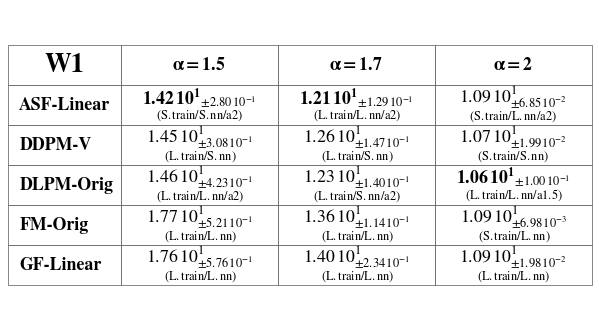

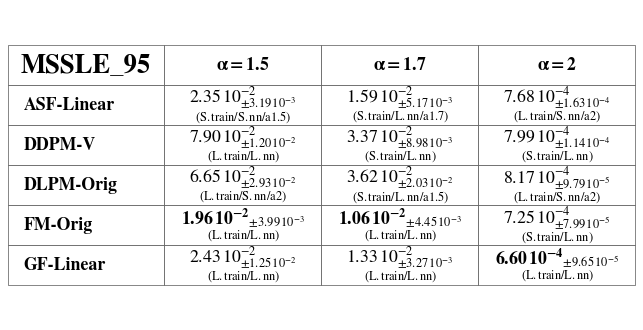

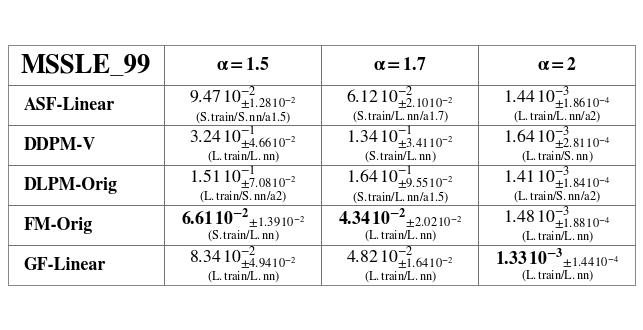

In [9]:
for metric in metric_order:
    winners = best_table_df(summary_exact, metric)
    table = pd.DataFrame(
        index=sorted(winners["model_label"].unique()),
        columns=sorted(winners["dataset_alpha"].unique()),
        dtype=object,
    )
    for dataset_alpha, group in winners.groupby("dataset_alpha"):
        best_model = group.nsmallest(1, f"{metric}_mean").iloc[0]["model_label"]
        for _, row in group.iterrows():
            value = format_mean_std_latex(
                row[f"{metric}_mean"],
                row[f"{metric}_std"],
                caption=setting_code(row),
                bold=row["model_label"] == best_model,
            )
            table.loc[row["model_label"], dataset_alpha] = value

    fig, ax = plt.subplots(1, 1, figsize=(0.8 + len(table.columns), 0.8 + 0.35 * len(table.index)))
    ax.axis("off")
    mtbl = ax.table(
        cellText=table.values,
        rowLabels=list(table.index),
        colLabels=[rf"$\mathbf{{\alpha={alpha:.3g}}}$" for alpha in table.columns],
        loc="center",
        cellLoc="center",
    )
    mtbl.auto_set_font_size(False)
    mtbl.set_fontsize(8)
    mtbl.scale(1.0, 1.5)
    corner_width = mtbl[(1, -1)].get_width() if (1, -1) in mtbl.get_celld() else mtbl[(1, 0)].get_width()
    corner_height = mtbl[(0, 0)].get_height()
    mtbl.add_cell(0, -1, width=corner_width, height=corner_height, text=metric, loc="center")
    for (row, col), cell in mtbl.get_celld().items():
        cell.set_edgecolor("0.3")
        cell.set_linewidth(0.3)
        if col == -1:
            cell.set_text_props(weight="bold")
    plt.show()


In [ ]:
inspect_table = pd.DataFrame(index=["Init. Error", "Train Error"], columns=label_order, dtype=object)
best_by_inspect = {
    metric_name: inspect_summary[metric_name].map(lambda d: d["mean"]).idxmin()
    for metric_name in ["err_init", "err_train"]
}

for model_label in label_order:
    inspect_table.loc["Init. Error", model_label] = format_mean_std_latex(
        inspect_summary.loc[model_label, "err_init"]["mean"],
        inspect_summary.loc[model_label, "err_init"]["std"],
        bold=model_label == best_by_inspect["err_init"],
    )
    inspect_table.loc["Train Error", model_label] = format_mean_std_latex(
        inspect_summary.loc[model_label, "err_train"]["mean"],
        inspect_summary.loc[model_label, "err_train"]["std"],
        bold=model_label == best_by_inspect["err_train"],
    )

fig, axis = plt.subplots(1, 1, figsize=(1.2 * len(label_order) + 1.0, 1.4), squeeze=False)
axis[0, 0].axis("off")
table = axis[0, 0].table(
    cellText=inspect_table.values,
    rowLabels=list(inspect_table.index),
    colLabels=label_order,
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.35)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("0.2")
    cell.set_linewidth(0.6)
    if row == 0 or col == -1:
        cell.set_text_props(weight="bold")

plt.show()


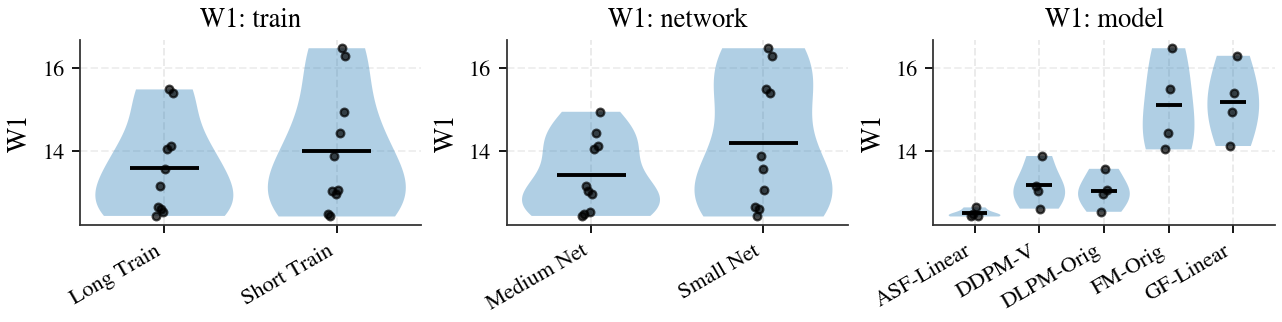

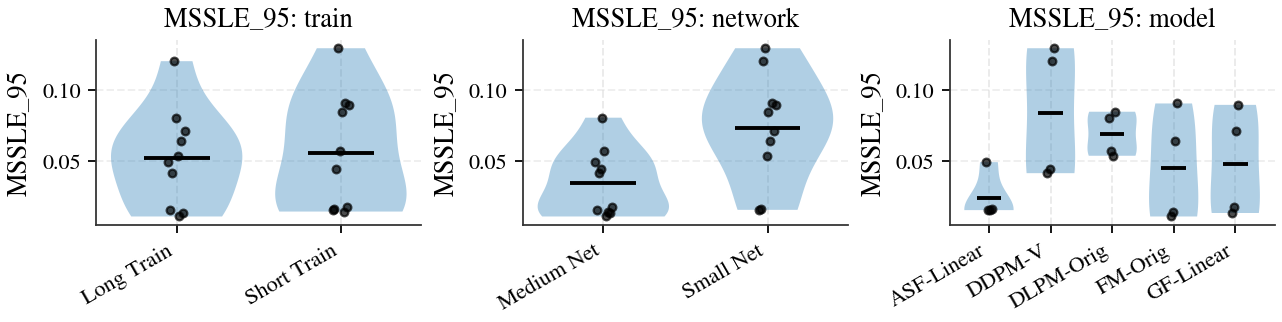

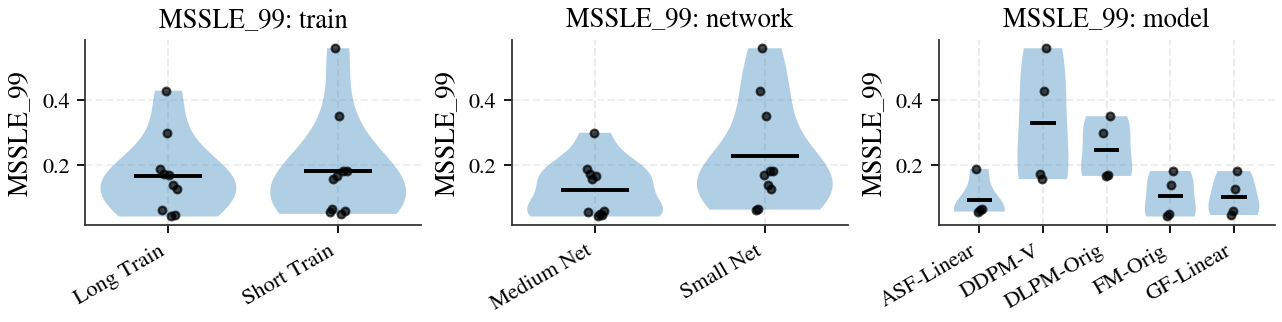

In [10]:
label_maps = {
    "train_preset": {"short": "Short Train", "long": "Long Train"},
    "network_preset": {"mlp_small": "Small Net", "mlp_medium": "Medium Net"},
}

for metric in ["W1", "MSSLE_95", "MSSLE_99"]:
    agg = aggregated_best_alpha(summary_exact, metric)
    groups = [
        ("train_preset", f"{metric}: train"),
        ("network_preset", f"{metric}: network"),
        ("model_label", f"{metric}: model"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(8.0, 2.0), constrained_layout=True)
    for ax, (column, title) in zip(axes, groups):
        label_map = label_maps.get(column, {})
        series_by_label = {label_map.get(key, key): grp[metric].to_numpy() for key, grp in agg.groupby(column)}
        grouped_violin(ax, series_by_label, title, metric)
    plt.show()


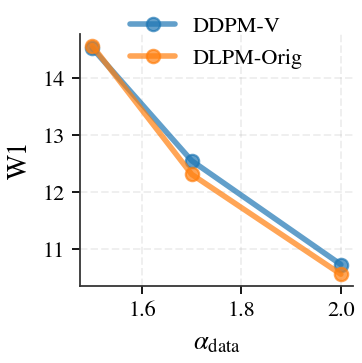

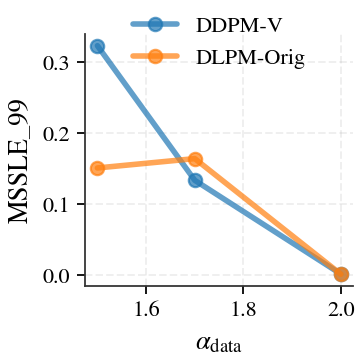

In [47]:
source_pairs = [("DDPM-V", "DLPM-Orig", "Diffusion baselines")]

for metric in ["W1", "MSSLE_99"]:
    reduced = reduce_best_alpha(summary_exact, metric)
    best_over_net_train = (
        reduced.sort_values(f"{metric}_mean")
        .groupby(["dataset_alpha", "model_label"], dropna=False)
        .first()
        .reset_index()
    )
    fig, axes = plt.subplots(1, 1, figsize=(2.25, 2.25), constrained_layout=True, squeeze=False)
    for ax, (left_model, right_model, title) in zip(axes.flat, source_pairs):
        sub = best_over_net_train[best_over_net_train["model_label"].isin([left_model, right_model])]
        for model_label, group in sub.groupby("model_label"):
            group = group.sort_values("dataset_alpha")
            ax.plot(group["dataset_alpha"], group[f"{metric}_mean"], marker="o", lw=2.5, label=model_label, alpha=0.7)
        ax.set_xlabel(r"$\alpha_{\mathrm{data}}$")
        ax.set_ylabel(metric)
        ax.grid(alpha=0.2)
        ax.legend(ncol=1, loc="upper center", bbox_to_anchor=(0.5, 1.15), frameon=False, fontsize=10)
    plt.show()


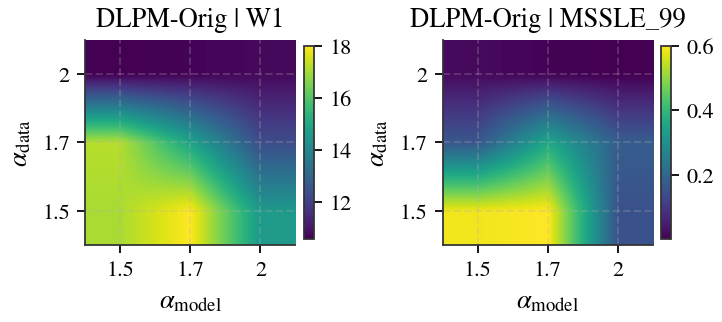

In [12]:
for model_label in ["DLPM-Orig"]:
    fig, axes = plt.subplots(1, 2, figsize=(4.5, 2.0), constrained_layout=True)
    sub = summary_exact[summary_exact["model_label"] == model_label].copy()
    for ax, metric in zip(axes, ["W1", "MSSLE_99"]):
        best = (
            sub.sort_values(f"{metric}_mean")
            .groupby(["dataset_alpha", "model_alpha"], dropna=False)
            .first()
            .reset_index()
        )
        pivot = best.pivot(index="dataset_alpha", columns="model_alpha", values=f"{metric}_mean").sort_index().sort_index(axis=1)
        image = ax.imshow(pivot.values, origin="lower", aspect="auto", interpolation="bilinear")
        ax.set_title(f"{model_label} | {metric}")
        ax.set_xlabel(r"$\alpha_{\mathrm{model}}$")
        ax.set_ylabel(r"$\alpha_{\mathrm{data}}$")
        ax.set_xticks(np.arange(len(pivot.columns)), [f"{x:.3g}" for x in pivot.columns])
        ax.set_yticks(np.arange(len(pivot.index)), [f"{x:.3g}" for x in pivot.index])
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.show()


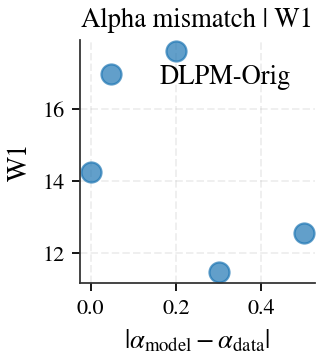

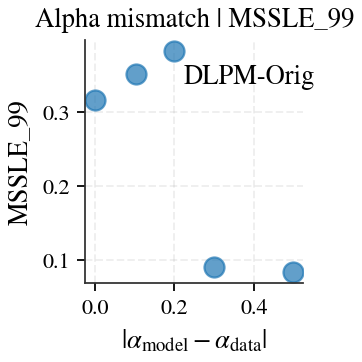

In [13]:
def _average_curve(curves):
    if not curves:
        return None, None
    max_epoch = max(total_epochs for total_epochs, _ in curves)
    epoch_grid = np.arange(1, max_epoch + 1, dtype=float)
    aligned = []
    for total_epochs, curve in curves:
        x_curve = np.linspace(1.0, float(total_epochs), num=len(curve), dtype=float)
        aligned.append(np.interp(epoch_grid, x_curve, curve, left=np.nan, right=np.nan))
    return epoch_grid, np.nanmean(np.stack(aligned, axis=0), axis=0)

loss_by_model = {label: _average_curve(train_curves[label]["training_loss"]) for label in label_order}
grad_var_by_model = {label: _average_curve(train_curves[label]["grad_variance_epoch"]) for label in label_order}
grad_norm_by_model = {label: _average_curve(train_curves[label]["grad_norm_epoch"]) for label in label_order}
max_epochs = max(epochs[-1] for epochs, curve in loss_by_model.values() if epochs is not None and curve is not None)
epoch_budgets = sorted({int(total_epochs) for curves_by_key in train_curves.values() for curves in curves_by_key.values() for total_epochs, _ in curves})
xticks = [1] + [epoch for epoch in epoch_budgets if epoch > 1]

fig, axes = plt.subplots(1, 3, figsize=(1.5 * len(label_order), 2.0), constrained_layout=True)
for label in label_order:
    style = style_map[label]
    epochs, curve = loss_by_model[label]
    if curve is not None:
        axes[0].plot(epochs, curve, color=style["color"], linestyle=style["linestyle"], lw=2.0, alpha=0.7, label=label)
    epochs, curve = grad_var_by_model[label]
    if curve is not None:
        axes[1].plot(epochs, curve, color=style["color"], linestyle=style["linestyle"], lw=2.0, alpha=0.7)
    epochs, curve = grad_norm_by_model[label]
    if curve is not None:
        axes[2].plot(epochs, curve, color=style["color"], linestyle=style["linestyle"], lw=2.0, alpha=0.7)

for ax, ylabel in zip(axes, ["Loss", "Var. Grad.", "Norm. Grad."]):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1, max_epochs)
    ax.set_xticks(xticks, [str(int(tick)) for tick in xticks])
    ax.set_xlabel("Epochs")
    ax.set_ylabel(ylabel)

fig.legend(ncol=len(label_order), loc="upper center", bbox_to_anchor=(0.5, 1.15), frameon=False, fontsize=9)
plt.show()


/tmp/ipykernel_143440/1674980224.py:47: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


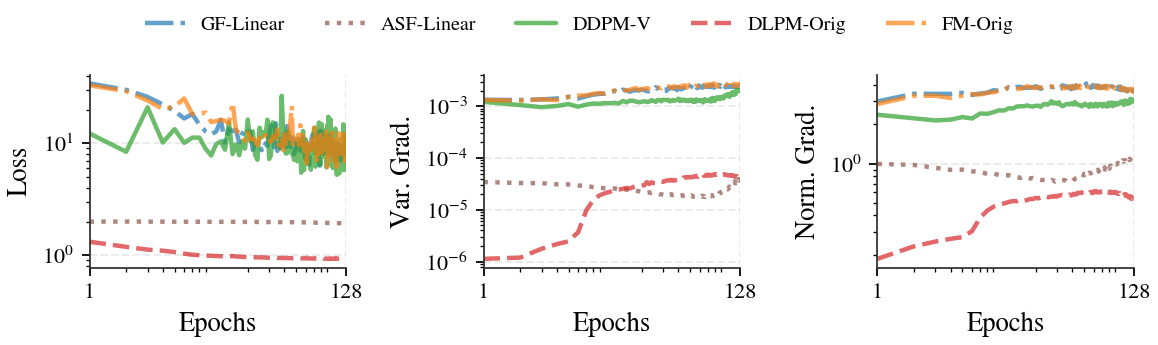

In [14]:
def _average_curve(curves):
    if not curves:
        return None
    min_len = min(len(curve) for curve in curves)
    return np.mean(np.stack([curve[:min_len] for curve in curves], axis=0), axis=0)

avg_loss_by_model = {label: _average_curve(train_curves[label]["training_loss"]) for label in label_order}
avg_grad_var_by_model = {label: _average_curve(train_curves[label]["grad_variance_epoch"]) for label in label_order}
avg_grad_norm_by_model = {label: _average_curve(train_curves[label]["grad_norm_epoch"]) for label in label_order}
max_loss_epochs = max(curve.size for curve in avg_loss_by_model.values() if curve is not None)
max_grad_var_epochs = max(curve.size for curve in avg_grad_var_by_model.values() if curve is not None)
max_grad_norm_epochs = max(curve.size for curve in avg_grad_norm_by_model.values() if curve is not None)

fig, axes = plt.subplots(1, 3, figsize=(1.5 * len(label_order), 2.0), constrained_layout=True)
for label in label_order:
    style = style_map[label]
    if avg_loss_by_model[label] is not None:
        axes[0].plot(np.arange(1, avg_loss_by_model[label].size + 1), avg_loss_by_model[label], color=style["color"], linestyle=style["linestyle"], lw=2.0, alpha=0.7, label=label)
    if avg_grad_var_by_model[label] is not None:
        axes[1].plot(np.arange(1, avg_grad_var_by_model[label].size + 1), avg_grad_var_by_model[label], color=style["color"], linestyle=style["linestyle"], lw=2.0, alpha=0.7)
    if avg_grad_norm_by_model[label] is not None:
        axes[2].plot(np.arange(1, avg_grad_norm_by_model[label].size + 1), avg_grad_norm_by_model[label], color=style["color"], linestyle=style["linestyle"], lw=2.0, alpha=0.7)

axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim(1, max_loss_epochs)
axes[0].set_xticks([1, max_loss_epochs], ["1", f"{max_loss_epochs}"])
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")

axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim(1, max_grad_var_epochs)
axes[1].set_xticks([1, max_grad_var_epochs], ["1", f"{max_grad_var_epochs}"])
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Var. Grad.")

axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlim(1, max_grad_norm_epochs)
axes[2].set_xticks([1, max_grad_norm_epochs], ["1", f"{max_grad_norm_epochs}"])
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("Norm. Grad.")

fig.legend(ncol=len(label_order), loc="upper center", bbox_to_anchor=(0.5, 1.15), frameon=False, fontsize=9)

fig.tight_layout()

plt.show()


/tmp/ipykernel_143440/6861302.py:22: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


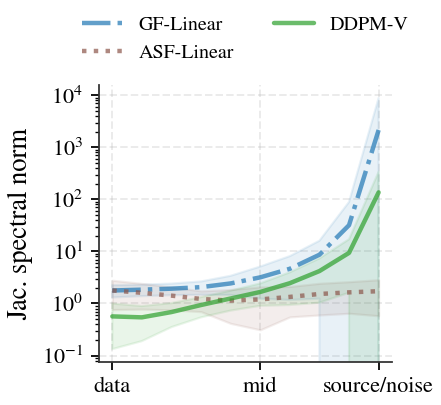

In [15]:
fig, ax = plt.subplots(figsize=(3.0, 2.8), constrained_layout=True)
for label in label_order:
    curves = jacobian_runs[label]
    if not curves:
        continue
    min_len = min(len(curve) for curve in curves)
    stack = np.stack([curve[:min_len] for curve in curves], axis=0)
    avg_curve = stack.mean(axis=0)
    std_curve = stack.std(axis=0)
    x = np.arange(min_len)
    style = style_map[label]
    ax.plot(x, avg_curve, color=style["color"], linestyle=style["linestyle"], lw=2.0, alpha=0.7, label=label)
    ax.fill_between(x, avg_curve - std_curve, avg_curve + std_curve, color=style["color"], alpha=0.1)

if any(jacobian_runs[label] for label in label_order):
    n_pts = min(len(curve) for label in label_order for curve in jacobian_runs[label])
    ax.set_xticks([0, n_pts // 2, n_pts - 1], ["data", "mid", "source/noise"])
ax.set_yscale("log")
ax.set_ylabel("Jac. spectral norm")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=9)

fig.tight_layout()

plt.show()


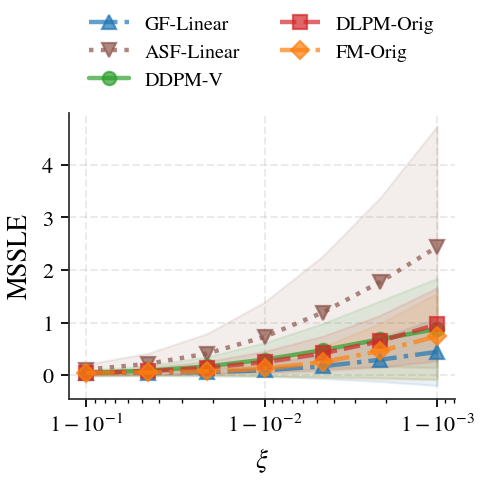

In [ ]:
fig, ax = plt.subplots(figsize=(3.0, 3.0), constrained_layout=True)
for label in label_order:
    curves = tail_runs[label]
    if not curves:
        continue
    stack = np.stack(curves, axis=0)
    avg_curve = stack.mean(axis=0)
    std_curve = stack.std(axis=0)
    style = style_map[label]
    ax.plot(xis, avg_curve, color=style["color"], linestyle=style["linestyle"], marker=style["marker"], lw=2.0, alpha=0.7, label=label)
    ax.fill_between(xis, avg_curve - std_curve, avg_curve + std_curve, color=style["color"], alpha=0.1)

ax.set_xscale("logit")
ax.set_xlabel(r"$\xi$")
ax.set_ylabel("MSSLE")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=9)
plt.show()
